<a href="https://colab.research.google.com/github/uxntani/AI-LAB/blob/main/2026_09_11_Lab1_Problem3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Adjacency list:
  A: ['B', 'C']
  B: ['A', 'D']
  C: ['A', 'D', 'E']
  D: ['B', 'C']
  E: ['C']
  F: ['G']
  G: ['F', 'H']
  H: ['G']
  I: []

Route checks:
  A -> E : route exists -> A -> B -> D -> C -> E
  B -> H : no route exists

Connected components found: 3
  Component 1: ['A', 'B', 'C', 'D', 'E']
  Component 2: ['F', 'G', 'H']
  Component 3: ['I']


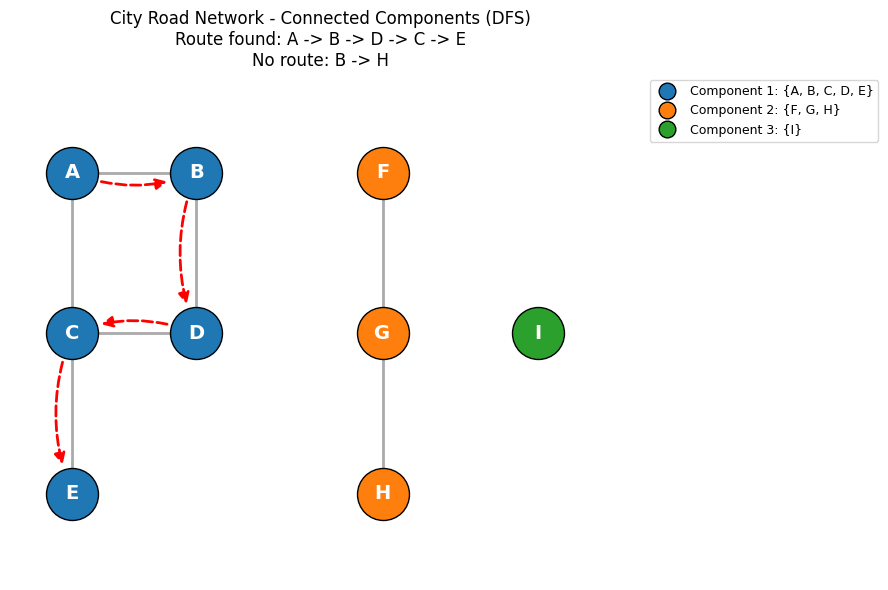

In [1]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
roads = [
    ("A", "B"), ("A", "C"), ("B", "D"), ("C", "D"), ("C", "E"),
    ("F", "G"), ("G", "H"),
]
cities = ["A", "B", "C", "D", "E", "F", "G", "H", "I"]
graph = {city: [] for city in cities}
for u, v in roads:
    graph[u].append(v)
    graph[v].append(u)

def find_route(graph, start, end):
    visited = set()

    def dfs(city, path):
        visited.add(city)
        path = path + [city]
        if city == end:
            return path
        for neighbour in graph[city]:
            if neighbour not in visited:
                result = dfs(neighbour, path)
                if result is not None:
                    return result
        return None

    return dfs(start, [])

def connected_components(graph):
    visited = set()
    components = []

    def dfs(city, component):
        visited.add(city)
        component.append(city)
        for neighbour in graph[city]:
            if neighbour not in visited:
                dfs(neighbour, component)

    for city in graph:
        if city not in visited:
            component = []
            dfs(city, component)
            components.append(sorted(component))

    return components

POS = {
    "A": (0, 2), "B": (2, 2), "C": (0, 0.7), "D": (2, 0.7), "E": (0, -0.6),
    "F": (5, 2), "G": (5, 0.7), "H": (5, -0.6),
    "I": (7.5, 0.7),
}

PALETTE = ["#1f77b4", "#ff7f0e", "#2ca02c", "#9467bd", "#8c564b"]

def draw_network(graph, components, good_query, bad_query, filename="city_routes.png"):
    fig, ax = plt.subplots(figsize=(9, 6))
    drawn = set()
    for u in graph:
        for v in graph[u]:
            if (v, u) not in drawn:
                x1, y1 = POS[u]
                x2, y2 = POS[v]
                ax.plot([x1, x2], [y1, y2], color="#aaaaaa", lw=2, zorder=1)
                drawn.add((u, v))
    city_colour = {}
    for i, comp in enumerate(components):
        for city in comp:
            city_colour[city] = PALETTE[i % len(PALETTE)]

    for city, (x, y) in POS.items():
        ax.scatter(x, y, s=1400, color=city_colour[city], edgecolor="black", zorder=3)
        ax.text(x, y, city, ha="center", va="center",
                fontsize=14, fontweight="bold", color="white", zorder=4)
    if good_query is not None:
        path = good_query
        for a, b in zip(path, path[1:]):
            ax.add_patch(
                FancyArrowPatch(
                    POS[a], POS[b],
                    connectionstyle="arc3,rad=0.2",
                    arrowstyle="-|>", mutation_scale=16,
                    color="red", lw=2, linestyle="--",
                    shrinkA=22, shrinkB=22, zorder=2,
                )
            )
        route_label = f"Route found: {' -> '.join(path)}"
    else:
        route_label = ""
    handles = [
        plt.Line2D([0], [0], marker="o", linestyle="", markersize=12,
                    markerfacecolor=PALETTE[i % len(PALETTE)], markeredgecolor="black",
                    label=f"Component {i + 1}: {{{', '.join(comp)}}}")
        for i, comp in enumerate(components)
    ]
    ax.legend(handles=handles, loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=9)
    title = "City Road Network - Connected Components (DFS)"
    if route_label:
        title += f"\n{route_label}"
    if bad_query is not None:
        title += f"\nNo route: {bad_query[0]} -> {bad_query[1]}"
    ax.set_title(title, fontsize=12)
    ax.set_xlim(-1, 9)
    ax.set_ylim(-1.3, 2.8)
    ax.axis("off")
    fig.tight_layout()
    fig.savefig(filename, dpi=150, bbox_inches="tight")
    return fig

if __name__ == "__main__":
    print("Adjacency list:")
    for city, neighbours in graph.items():
        print(f"  {city}: {neighbours}")
    query1 = ("A", "E")
    query2 = ("B", "H")
    print("\nRoute checks:")
    path1 = find_route(graph, *query1)
    if path1:
        print(f"  {query1[0]} -> {query1[1]} : route exists -> {' -> '.join(path1)}")
    else:
        print(f"  {query1[0]} -> {query1[1]} : no route exists")
    path2 = find_route(graph, *query2)
    if path2:
        print(f"  {query2[0]} -> {query2[1]} : route exists -> {' -> '.join(path2)}")
    else:
        print(f"  {query2[0]} -> {query2[1]} : no route exists")
    components = connected_components(graph)
    print(f"\nConnected components found: {len(components)}")
    for i, comp in enumerate(components, start=1):
        print(f"  Component {i}: {comp}")
    draw_network(graph, components, good_query=path1, bad_query=query2 if not path2 else None)
    plt.show()